<a href="https://colab.research.google.com/github/Pema-Codes/diabetes-prediction-project/blob/main/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import and Environment Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Framework & Pipeline Tools
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Preprocessing & Imbalance Handling
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Visualization (UMAP)
# Installs UMAP-learn if not already present
!pip install umap-learn
try:
    from umap import UMAP # Uniform Manifold Approximation and Projection for dimension reduction
except ImportError:
    print("UMAP not detected. Run: !pip install umap-learn")

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import(
    accuracy_score, # Overall prediction accuracy
    roc_auc_score, # Area Under the Receiver Operating Characteristic Curve
    classification_report, # Text report showing main classification metrics
    confusion_matrix, # Matrix summarizing classification performance
    ConfusionMatrixDisplay, # Visual display of the confusion matrix
    RocCurveDisplay # Visual display of the ROC curve
)

# Set visual style for charts
plt.style.use('ggplot') # Use ggplot style for plots
np.random.seed(42) # Set a random seed for reproducibility
%matplotlib inline

###Loading the data

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
file = '/content/drive/MyDrive/Datasets/diabetes_prediction_dataset.csv'

In [9]:
def load_path(path: str) -> pd.DataFrame:
  df = pd.read_csv(path)
  df.columns= df.columns.str.strip()
  return df

# Exploratory Data Analysis

In [10]:
def inspect_data(df:pd.DataFrame):
  print("Shape:", df.shape)
  print("\nData types:\n", df.dtypes)
  print("\nMissing values:\n", df.isnull().sum())
  print("\nMissing values percentage:\n",(df.isnull().sum() / len(df)) * 100)
  print("\nUnique categories per column:\n ")
  for c in df.columns:
    print(f"-{c}: {df[c].nunique()}")
  display(df.head())

#Loading the dataset
df = load_path(file)
inspect_data(df)

Shape: (100000, 9)

Data types:
 gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Missing values percentage:
 gender                 0.0
age                    0.0
hypertension           0.0
heart_disease          0.0
smoking_history        0.0
bmi                    0.0
HbA1c_level            0.0
blood_glucose_level    0.0
diabetes               0.0
dtype: float64

Unique categories per column:
 
-gender: 3
-age: 102
-hypertension: 2
-heart_disease: 2
-smoking_history: 6
-bmi: 4247
-HbA1c_leve

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [11]:
df.head(20)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


## Data Visualization

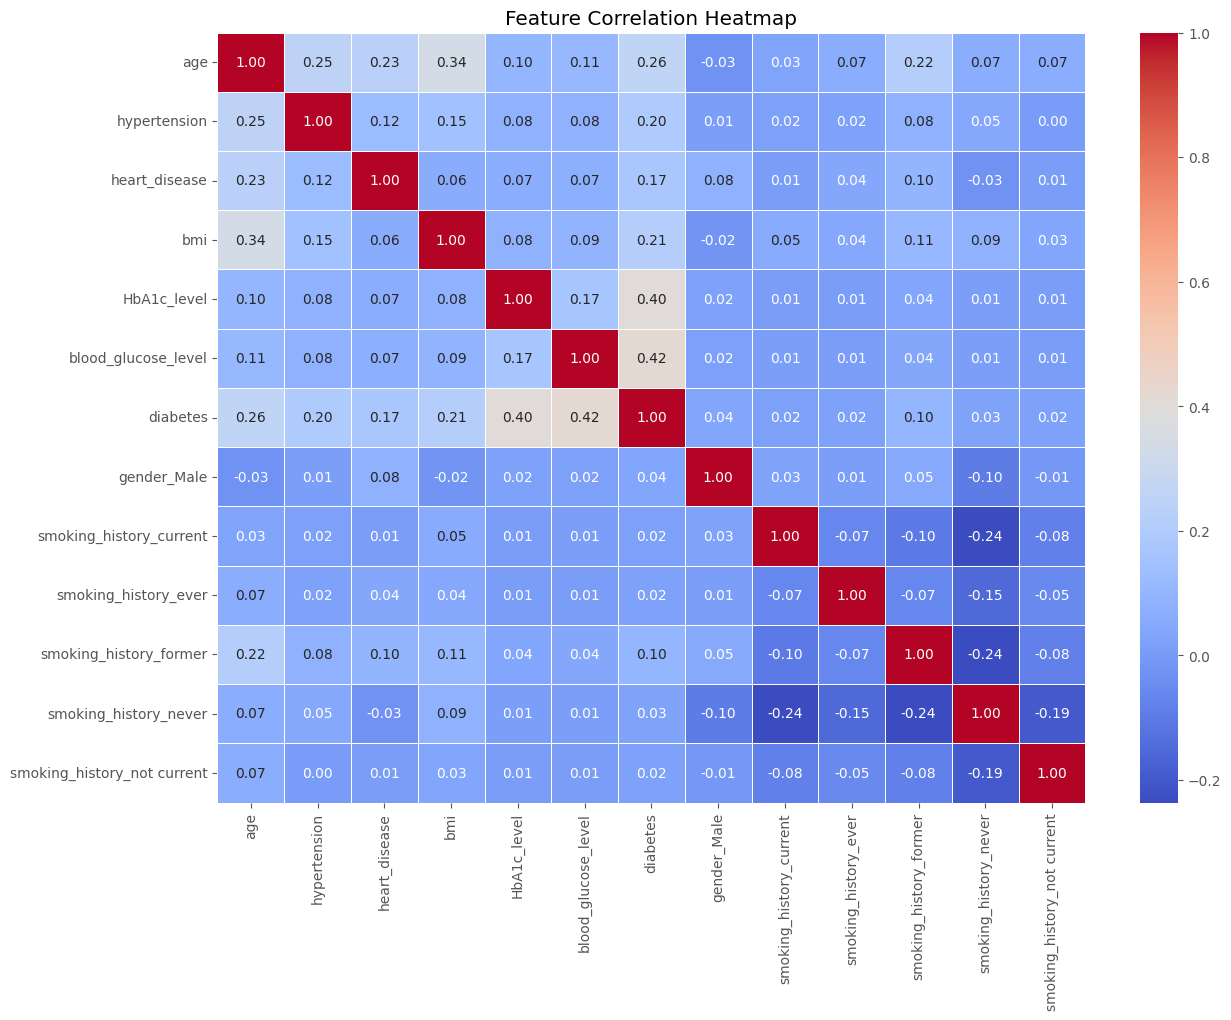

In [18]:
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

#Data Preprocessing

Inspecting the unique values in the gender and smoking_history columns to understand why gender has 3 categories so that we can apply appropriate preprocessing steps like one hot encoding for these categorical features

In [14]:
print('Unique values for gender:', df['gender'].unique())
print('Unique values for smoking_history:', df['smoking_history'].unique())

Unique values for gender: ['Female' 'Male' 'Other']
Unique values for smoking_history: ['never' 'No Info' 'current' 'former' 'ever' 'not current']


## Preprocessing Categorical Features
Examining the value counts for `gender` and `smoking_history` to understand the distribution of categories, especially the 'Other' gender and 'No Info' smoking history.

In [15]:
print('Gender value counts:\n', df['gender'].value_counts())
print('\nSmoking history value counts:\n', df['smoking_history'].value_counts())

Gender value counts:
 gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Smoking history value counts:
 smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


## Handling 'Other' Gender and One-Hot Encoding Categorical Features

Since the 'Other' category in `gender` is extremely small (18 entries), it's generally best to handle it rather than letting it create a very sparse feature after one-hot encoding. I'll reassign 'Other' to 'Female', as 'Female' is the majority class. Following this, I'll apply one-hot encoding to both the `gender` and `smoking_history` columns to convert them into numerical representations.

In [16]:
# Reassign 'Other' gender to 'Female'
df['gender'] = df['gender'].replace('Other', 'Female')

# Verify the change
print('Gender value counts after remapping:\n', df['gender'].value_counts())

Gender value counts after remapping:
 gender
Female    58570
Male      41430
Name: count, dtype: int64


In [17]:
# Apply one-hot encoding to 'gender' and 'smoking_history'
df = pd.get_dummies(df, columns = ['gender', 'smoking_history'], drop_first = True)

#Display the first few rows with the new columns
display(df.head())

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,True,False,False,False,False


# Checking Class Imbalance

Examining the class distribution of the  (`diabetes`) column the DataFrame `df` to see if there's a significant imbalance.

Target Class Distribution (overall):
 diabetes
0    91500
1     8500
Name: count, dtype: int64

Percentage of each class (overall):
 diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


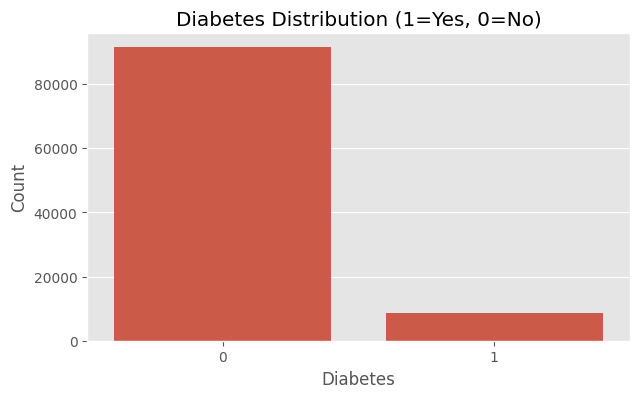

In [19]:
print("Target Class Distribution (overall):\n", df['diabetes'].value_counts())
print("\nPercentage of each class (overall):\n", df['diabetes'].value_counts(normalize=True) * 100)
plt.figure(figsize = (7,4))
sns.countplot(x = "diabetes", data=df)
plt.title("Diabetes Distribution (1=Yes, 0=No)")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

In [20]:
df = df.drop_duplicates().reset_index (drop= True)
print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (96142, 13)


# Feature and Target Separation, Data Splitting, and Standardization

Prepare the data for model training by separating the features (independent variables) from the target variable (dependent variable). The target variable here is `diabetes`.

After separation, split the dataset into training and testing sets. This is a crucial step to evaluate the performance of our machine learning models on unseen data. A common split ratio is 80% for training and 20% for testing. Finally, we'll apply `StandardScaler` to our numerical features. Standardization is important to ensure that features with larger scales do not disproportionately influence the model's learning process.

In [21]:
# Separate features (X) and target (y)

X = df.drop('diabetes', axis=1)
y = df['diabetes']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (96142, 12)
Shape of target (y): (96142,)


In [22]:
#Split data into training and testing sets
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train_raw.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train_raw.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (76913, 12)
Shape of X_test: (19229, 12)
Shape of y_train: (76913,)
Shape of y_test: (19229,)


In [23]:
# Identify numerical columns for standardization
numerical_cols = X_train_raw.select_dtypes(include=np.number).columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Create copies to avoid SettingWithCopyWarning and ensure DataFrame structure
# Then apply StandardScaler to numerical features in training and testing sets
# X_train will hold the scaled training features
X_train = X_train_raw.copy()
X_train[numerical_cols] = scaler.fit_transform(X_train_raw[numerical_cols])

# X_test will hold the scaled test features (using parameters from training data)
X_test_scaled = X_test.copy()
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# y_train will be used by SMOTE, it's just the raw training labels
y_train = y_train_raw

print("First 5 rows of scaled X_train:")
display(X_train.head())

First 5 rows of scaled X_train:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
6432,-0.437083,-0.291195,-0.207844,-0.315806,-0.683739,-1.426250,False,False,False,False,False,False
56228,-0.748653,-0.291195,-0.207844,0.001417,0.997494,-1.426250,False,False,False,False,True,False
36807,1.031746,-0.291195,-0.207844,0.001417,0.904092,0.532773,False,True,False,False,False,False
18156,0.319587,-0.291195,-0.207844,0.001417,-0.683739,-1.181372,True,True,False,False,False,False
2564,0.453117,3.434130,-0.207844,0.606353,0.156878,0.508285,True,True,False,False,False,False


### Handling Class Imbalance with SMOTE

As observed from the class distribution, our dataset is imbalanced (approximately 91.5% non-diabetic and 8.5% diabetic). This imbalance can lead to models that perform poorly on the minority class, as they tend to be biased towards the majority class.

To address this, **SMOTE (Synthetic Minority Over-sampling Technique)** will be used. SMOTE works by creating synthetic samples for the minority class, rather than simply duplicating existing ones. It selects a minority class instance and then finds its k-nearest neighbors. Synthetic instances are then created by taking the difference between the selected instance and its neighbors, multiplying by a random number between 0 and 1, and adding it to the selected instance. This effectively oversamples the minority class and helps to balance the dataset, leading to more robust model training.

In [24]:
# Initialize SMOTE
smote = SMOTE(random_state = 42)

#Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Original training data shape:", X_train.shape, y_train.shape)
print("Resampled training data shape:", X_train_resampled.shape, y_train_resampled.shape)

print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())
print(y_train_resampled.value_counts(normalize=True) * 100)

Original training data shape: (76913, 12) (76913,)
Resampled training data shape: (140254, 12) (140254,)

Class distribution after SMOTE:
diabetes
0    70127
1    70127
Name: count, dtype: int64
diabetes
0    50.0
1    50.0
Name: proportion, dtype: float64


## Model Training

In [25]:
#Initialize models
logistic_model = LogisticRegression(random_state = 42, solver = 'liblinear')
decision_tree_model = DecisionTreeClassifier(random_state = 42)
random_forest_model = RandomForestClassifier(random_state = 42)
xgb_model = XGBClassifier(random_state = 42, use_label_encoder = False, eval_metric = 'logloss')

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

#Training Models
for name, model in models.items():
  print(f"Training {name}...")
  model.fit(X_train_resampled, y_train_resampled)
  print(f"{name} trained successfully.")

Training Logistic Regression...
Logistic Regression trained successfully.
Training Decision Tree...
Decision Tree trained successfully.
Training Random Forest...
Random Forest trained successfully.
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:46:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained successfully.


## Model Evaluation

Evaluating Logistic Regression...
--- Logistic Regression Results ---
Accuracy: 0.8867
ROC AUC: 0.9604
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     17533
           1       0.43      0.88      0.58      1696

    accuracy                           0.89     19229
   macro avg       0.71      0.88      0.76     19229
weighted avg       0.94      0.89      0.90     19229





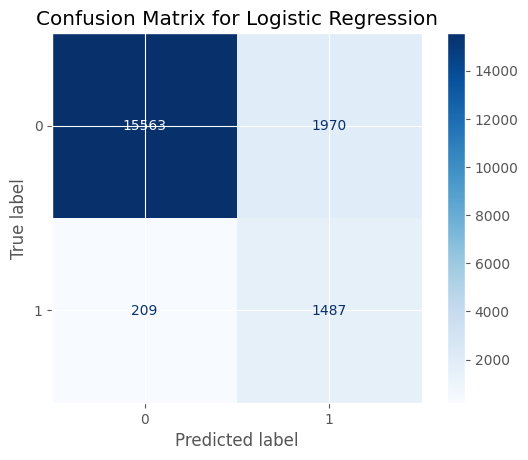

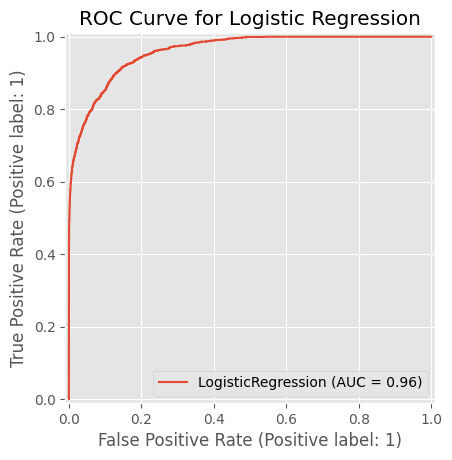

Evaluating Decision Tree...
--- Decision Tree Results ---
Accuracy: 0.9470
ROC AUC: 0.8588
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     17533
           1       0.68      0.75      0.71      1696

    accuracy                           0.95     19229
   macro avg       0.83      0.86      0.84     19229
weighted avg       0.95      0.95      0.95     19229





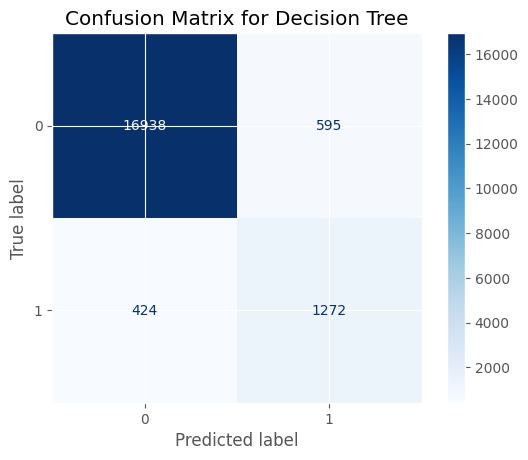

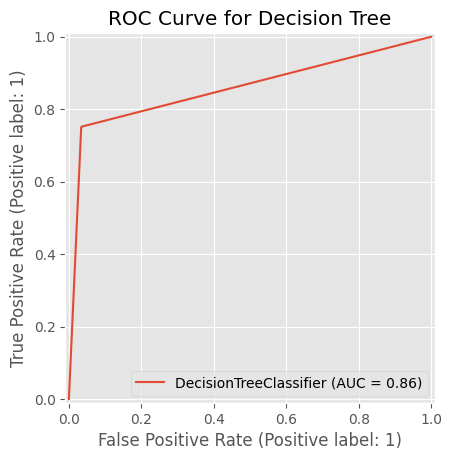

Evaluating Random Forest...
--- Random Forest Results ---
Accuracy: 0.9587
ROC AUC: 0.9653
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     17533
           1       0.77      0.75      0.76      1696

    accuracy                           0.96     19229
   macro avg       0.88      0.86      0.87     19229
weighted avg       0.96      0.96      0.96     19229





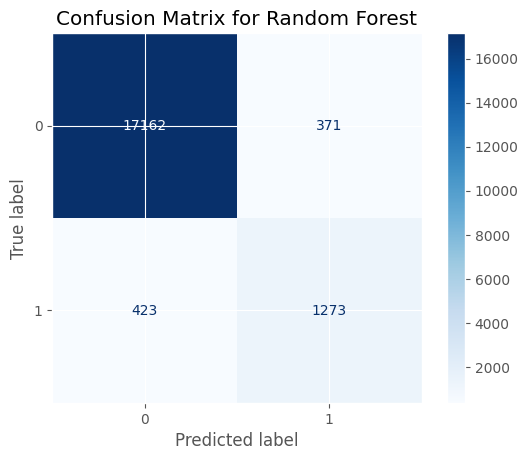

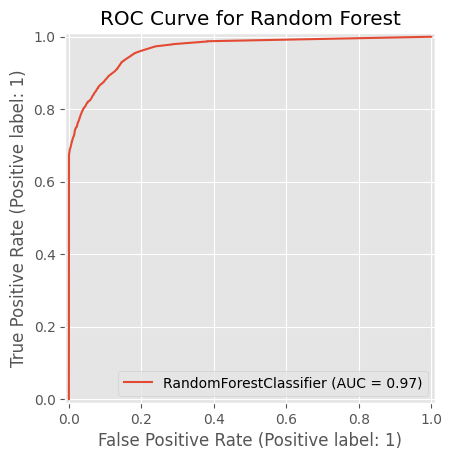

Evaluating XGBoost...
--- XGBoost Results ---
Accuracy: 0.9686
ROC AUC: 0.9757
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17533
           1       0.91      0.72      0.80      1696

    accuracy                           0.97     19229
   macro avg       0.94      0.85      0.89     19229
weighted avg       0.97      0.97      0.97     19229





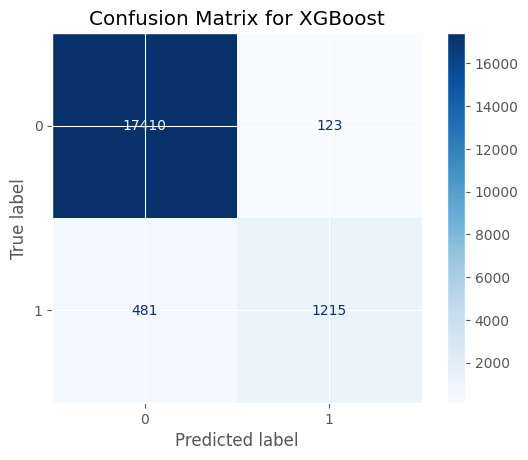

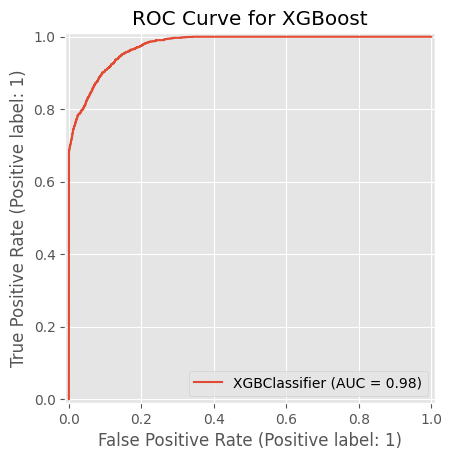

In [26]:
results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    # Make predictions on the scaled test set
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        "Accuracy": accuracy,
        "ROC AUC": roc_auc,
        "Classification Report": report
    }

    print(f"--- {name} Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n")

    # Display Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

    # Display ROC Curve
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
    plt.title(f'ROC Curve for {name}')
    plt.show()


## Model Performance Summary

In [27]:
print("--- Model Comparison Summary ---")

performance_data = []
for name, metrics in results.items():
    performance_data.append({
        "Model": name,
        "Accuracy": metrics["Accuracy"],
        "ROC AUC": metrics["ROC AUC"]
    })

performance_df = pd.DataFrame(performance_data)
performance_df = performance_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)

display(performance_df)

best_model_name = performance_df.loc[0, 'Model']
best_roc_auc = performance_df.loc[0, 'ROC AUC']

print(f"\nThe best performing model based on ROC AUC is: **{best_model_name}** with an ROC AUC score of **{best_roc_auc:.4f}**")

--- Model Comparison Summary ---


,Model,Accuracy,ROC AUC
0,XGBoost,0.968589,0.975685
1,Random Forest,0.958708,0.965311
2,Logistic Regression,0.886682,0.960422
3,Decision Tree,0.947007,0.858772



The best performing model based on ROC AUC is: **XGBoost** with an ROC AUC score of **0.9757**
